# Intro to plotting

<div style="background-color: #f2f9e6; border: 1px solid #d2eeb4; border-radius: 4px; padding: 15px;">

<h3 style="margin-top: 0; background-color: #daeebe; padding: 5px 10px; margin: -15px -15px 15px -15px; border-radius: 4px 4px 0 0; color: #2b542c;">
    ❓ Overview
</h3>  

#### **Questions**
* What is a shapefile? 
* How can I extract a subset of data?
* How can I plot a timeseries?

#### **Objectives**
* Intro to shapefiles
* Spatial extration (clipping to a shapefile)
* Plotting a (short) timeseries


</div>

## Resources


First, we are going to load 1 month of data. 

In [1]:
# import packages 
import requests 
import xarray as xr
import geopandas as gpd 
import rioxarray
import geopandas as gpd
from shapely.geometry import mapping
import matplotlib.pyplot as plt

# load ERDDAP URL 
url = 'https://comet.nefsc.noaa.gov/erddap/griddap/noaa_coastwatch_acspo_v2_reanalysis.nc?sea_surface_temperature%5B(2025-06-01T12:00:00Z):1:(2025-06-30T12:00:00Z)%5D%5B(34):1:(46)%5D%5B(-77):1:(-63)%5D'
url_new = requests.get(url,verify=False).content
ds = xr.open_dataset(url_new)

C:\Users\haley.synan\AppData\Local\anaconda3\Lib\site-packages\urllib3\connectionpool.py:1099: InsecureRequestWarning: Unverified HTTPS request is being made to host 'comet.nefsc.noaa.gov'. Adding certificate verification is strongly advised. See: https://urllib3.readthedocs.io/en/latest/advanced-usage.html#tls-warnings
  warnings.warn(


Now we can plot the first time step of the data 

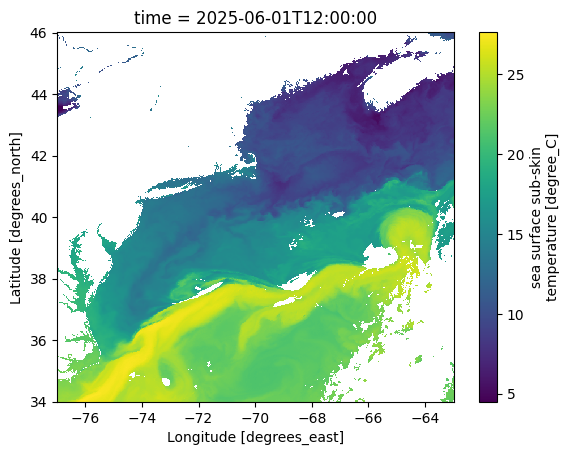

In [2]:
#create map of sst (first timestep)
ds.sea_surface_temperature[0].plot()

## Open a shapefile 
Now, we are going to use [geopandas](https://geopandas.org/en/stable/) to open a shapefile. A shapefile is a data storage format that is a collection of interconnected files that work together to draw points, lines, or polygons on a map. Here we will load a shapefile of the 5 regions of the Northeast US Continental Shelf. 

In [3]:
gdf = gpd.read_file('https://github.com/hsynan/READ-EDAB-Synan_hydrographic_climatologies/raw/refs/heads/main/data/shapefiles/NES_5REGIONS.zip')

In [4]:
gdf

,area,geometry
0,5.770158,"POLYGON ((-74.71113 36.50517, -74.71232 36.501..."
1,6.227196,"POLYGON ((-71.73448 39.95008, -71.74059 39.950..."
2,4.762347,"POLYGON ((-66.74085 40.75303, -66.74573 40.750..."
3,4.382310,"POLYGON ((-69.91489 42.02679, -69.98377 42.004..."
4,6.376634,"POLYGON ((-65.56925 42.16613, -65.68762 41.935..."


We can see that there are 5 separate polygons in this shapefile. 

<Axes: >

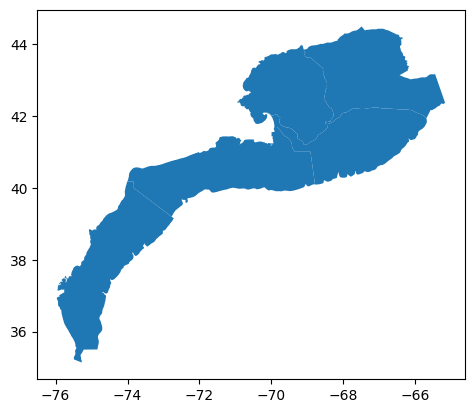

In [5]:
#visualize shapefile 
gdf.plot()

Now, we are going to extract a spatial subset from the SST data. We will use rioxarray to do this. 

In [6]:
# rioxarray requires spatial dimensions and CRS to be set
ds.rio.set_spatial_dims(x_dim="longitude", y_dim="latitude", inplace=True)
ds.rio.write_crs("epsg:4326", inplace=True)

# Clip the dataset
clipped_ds = ds.rio.clip(gdf.geometry.apply(mapping), gdf.crs, drop=True)


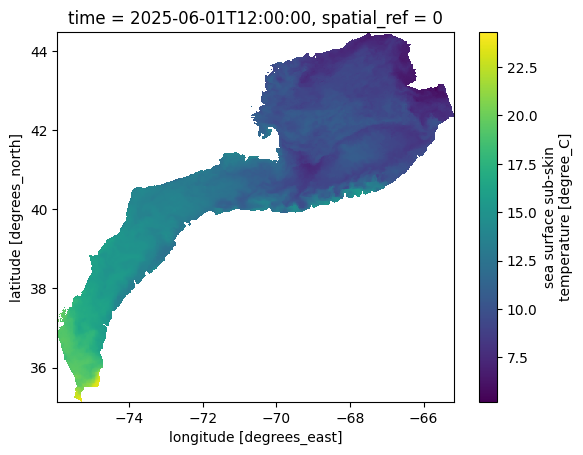

In [7]:
#visualize
clipped_ds.sea_surface_temperature[0].plot()

Instead of clipping to the shape of all 5 of the polygons, we can also choose 1 polygon from the shapefiles to clip to. We will now clip to the Georges Bank shapefile and visualize that

In [8]:
single_polygon = gdf.iloc[[2]]
gb_ds = ds.rio.clip(single_polygon.geometry.apply(mapping), single_polygon.crs, drop=True)

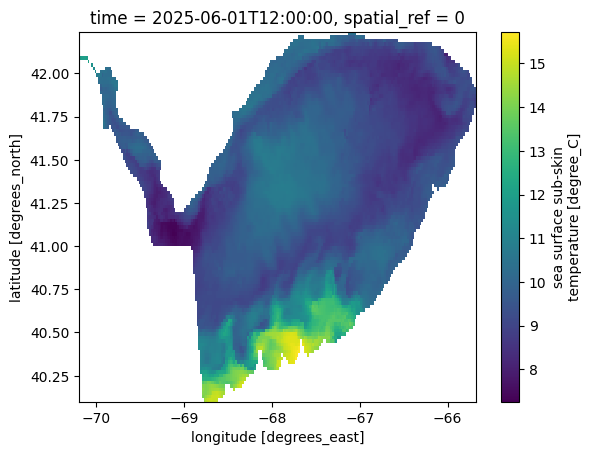

In [9]:
gb_ds.sea_surface_temperature[0].plot()

We can see we stil have the same dimensions, there are just fewer latitude and longitudes in this spatial subset. 

In [10]:
clipped_ds

<xarray.Dataset> Size: 29MB
Dimensions:                  (time: 29, latitude: 467, longitude: 539)
Coordinates:
  * time                     (time) datetime64[ns] 232B 2025-06-01T12:00:00 ....
  * latitude                 (latitude) float32 2kB 44.47 44.45 ... 35.17 35.15
  * longitude                (longitude) float32 2kB -75.95 -75.93 ... -65.19
    spatial_ref              int32 4B 0
Data variables:
    sea_surface_temperature  (time, latitude, longitude) float32 29MB nan ......
Attributes: (12/63)
    acknowledgement:                        Please acknowledge the use of the...
    aggregator_version:                     V1.00
    cdm_data_type:                          Grid
    col_count:                              18000
    col_start:                              0
    collation_version:                      2.11.0
    ...                                     ...
    summary:                                Sea surface temperature retrieval...
    testOutOfDate:                          now-95days
    time_coverage_end:                      2025-06-30T12:00:00Z
    time_coverage_start:                    2025-06-01T12:00:00Z
    title:                                  Satellite Sea Surface Temperature...
    Westernmost_Easting:                    -76.99

Now we are going to create some daily spatial averages. This means we are going to take a daily SST average across all of the Georges bank, aka averaging across latitude and longitude. 

In [11]:
mean_sst = gb_ds.sea_surface_temperature.mean(dim=['latitude','longitude']) #create daily spatial averages
min_sst = gb_ds.sea_surface_temperature.min(dim=['latitude','longitude']) #create daily spatial averages
max_sst = gb_ds.sea_surface_temperature.max(dim=['latitude','longitude']) #create daily spatial averages

Now, we can plot a timeseries of the month of data. We will plot min, max, and mean averages of each day of June 2025.

Text(0.5, 1.0, 'Daily SST averages for Georges Bank\nJune 2025')

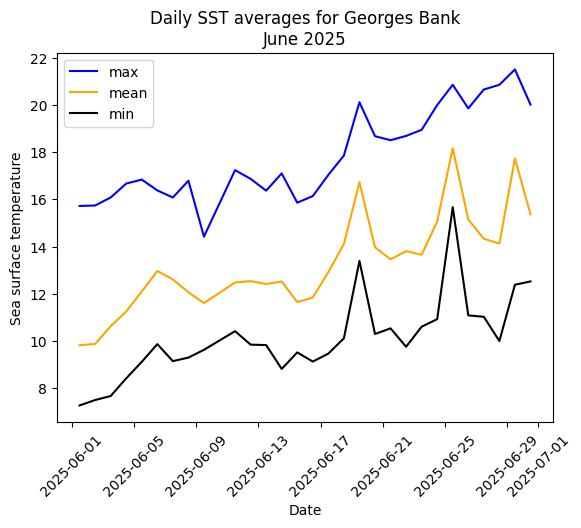

In [12]:
plt.plot(gb_ds.time,max_sst,c='blue',label='max')
plt.plot(gb_ds.time,mean_sst,c='orange',label='mean')
plt.plot(gb_ds.time,min_sst,c='black',label='min')
plt.legend()
plt.xticks(rotation=45)
plt.ylabel('Sea surface temperature')
plt.xlabel('Date')
plt.title('Daily SST averages for Georges Bank\nJune 2025')